## 1) Reproducibilidad, rutas y versiones

In [1]:
SEED = 42
from pathlib import Path
BASE_DIR = Path('./')

import numpy as np
np.random.seed(SEED)

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
import math
import datetime
import platform
import importlib.metadata as imp
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller

sns.set_style("darkgrid")
sns.set_context("poster")

print(f'Python Version == {platform.python_version()}')
paquetes =['matplotlib','numpy','pandas','seaborn','statsmodels','yfinance','scipy']
for paq in paquetes:
    print(f'{paq} == {imp.version(paq)}')
print(f'OS ==', platform.platform())

Python Version == 3.13.9
matplotlib == 3.10.6
numpy == 2.3.3
pandas == 2.3.3
seaborn == 0.13.2
statsmodels == 0.14.6
yfinance == 0.2.66
scipy == 1.16.2
OS == Windows-11-10.0.26200-SP0


## Carga y exploración de datos
Se cargan los datos en archivos `Datos_Energia.csv` y `Datos_Climaticos.csv`.

In [2]:
energia = pd.read_csv(BASE_DIR / 'Datos_Energia.csv')
clima = pd.read_csv(BASE_DIR / 'Datos_Climaticos.csv')

display(energia.head())

display(clima.head())

,Año,Mes,Día,Hora,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
0,2014,1,1,0,2,21294.33,2.39,8098.10352,876.28229,30268.37288,18880.0
1,2014,1,1,1,2,21190.46,1.95,7312.22987,873.35158,29377.43704,18320.0
2,2014,1,1,2,2,21537.07,4.29,7305.86410,911.45081,29752.56792,18560.0
3,2014,1,1,3,2,21688.66,9.65,7573.82433,870.42087,30130.62951,18790.0
4,2014,1,1,4,2,23044.40,10.19,7462.96849,946.61933,31455.31043,19620.0


,Año,Mes,Día,Hora,Día de la semana,Temperatura (°C),Punto de rocío (°C),Humedad (%),Dirección del viento,Velocidad del viento (m/s),Ráfaga de viento (m/s),Presión (hPa),Precipitación (mm),Condición meteorológica
0,2014,1,1,0,2,11.666667,-17.777778,45.0,CALMA,0.00000,0.0,977.312154,0.0,Despejado
1,2014,1,1,1,2,10.555556,0.555556,50.0,E,2.23520,0.0,977.312154,0.0,Despejado
2,2014,1,1,2,2,10.000000,-17.777778,50.0,ESE,1.34112,0.0,977.312154,0.0,Despejado
3,2014,1,1,3,2,9.444444,-17.777778,52.0,ESE,2.68224,0.0,977.312154,0.0,Despejado
4,2014,1,1,4,2,9.444444,-17.777778,52.0,CALMA,0.00000,0.0,977.650793,0.0,Despejado


# Rango fechas
Se convierten los datos de hora, dia, mes y año a fechas y se eliminan las columnas correspondientes.

In [3]:
energia['fecha'] = pd.to_datetime({
    'year':  energia['Año'],
    'month': energia['Mes'],
    'day':   energia['Día'],
    'hour':  energia['Hora']
})
energia.set_index('fecha', inplace=True)
#energia = energia.drop(columns=['Año', 'Mes', 'Día', 'Hora'])

clima['fecha'] = pd.to_datetime({
    'year':  clima['Año'],
    'month': clima['Mes'],
    'day':   clima['Día'],
    'hour':  clima['Hora']
})
clima.set_index('fecha', inplace=True)
#clima = clima.drop(columns=['Año', 'Mes', 'Día', 'Hora'])

display(energia)
display(clima)

,Año,Mes,Día,Hora,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
fecha,,,,,,,,,,,
2014-01-01 00:00:00,2014,1,1,0,2,21294.33,2.39,8098.10352,876.28229,30268.37288,18880.0
2014-01-01 01:00:00,2014,1,1,1,2,21190.46,1.95,7312.22987,873.35158,29377.43704,18320.0
2014-01-01 02:00:00,2014,1,1,2,2,21537.07,4.29,7305.86410,911.45081,29752.56792,18560.0
2014-01-01 03:00:00,2014,1,1,3,2,21688.66,9.65,7573.82433,870.42087,30130.62951,18790.0
2014-01-01 04:00:00,2014,1,1,4,2,23044.40,10.19,7462.96849,946.61933,31455.31043,19620.0
...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00,2022,12,31,19,5,15684.46,1.65,15884.38982,2464.72711,34031.40452,21220.0
2022-12-31 20:00:00,2022,12,31,20,5,15471.84,1.66,15171.98630,2496.96492,33137.53797,20670.0
2022-12-31 21:00:00,2022,12,31,21,5,15121.29,1.75,14711.04828,2526.27202,32357.96911,20180.0


,Año,Mes,Día,Hora,Día de la semana,Temperatura (°C),Punto de rocío (°C),Humedad (%),Dirección del viento,Velocidad del viento (m/s),Ráfaga de viento (m/s),Presión (hPa),Precipitación (mm),Condición meteorológica
fecha,,,,,,,,,,,,,,
2014-01-01 00:00:00,2014,1,1,0,2,11.666667,-17.777778,45.0,CALMA,0.00000,0.0,977.312154,0.0,Despejado
2014-01-01 01:00:00,2014,1,1,1,2,10.555556,0.555556,50.0,E,2.23520,0.0,977.312154,0.0,Despejado
2014-01-01 02:00:00,2014,1,1,2,2,10.000000,-17.777778,50.0,ESE,1.34112,0.0,977.312154,0.0,Despejado
2014-01-01 03:00:00,2014,1,1,3,2,9.444444,-17.777778,52.0,ESE,2.68224,0.0,977.312154,0.0,Despejado
2014-01-01 04:00:00,2014,1,1,4,2,9.444444,-17.777778,52.0,CALMA,0.00000,0.0,977.650793,0.0,Despejado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00,2022,12,31,19,5,16.666667,10.000000,65.0,E,3.12928,0.0,972.909847,0.0,Mayormente_nublado
2022-12-31 20:00:00,2022,12,31,20,5,15.000000,10.000000,72.0,E,2.23520,0.0,972.909847,0.0,Mayormente_nublado
2022-12-31 21:00:00,2022,12,31,21,5,15.000000,10.000000,72.0,E,1.34112,0.0,972.571208,0.0,Mayormente_nublado


# Comprobación de integriadad de fechas
Se comprueba si tenemos todo el rango de horas y fechas en el intervalo

In [4]:
fechas_esperadas_energia =  pd.date_range(start=energia.index.min(), end=energia.index.max(), freq='D')
fechas_perdidas_energia = fechas_esperadas_energia.difference(energia.index)
print(f'Número de fechas faltantes en datos de Energía: {len(fechas_perdidas_energia)}')

fechas_esperadas_clima =  pd.date_range(start=clima.index.min(), end=clima.index.max(), freq='D')
fechas_perdidas_clima = fechas_esperadas_clima.difference(clima.index)
print(f'Número de fechas faltantes en datos de Clima: {len(fechas_perdidas_clima)}')

Número de fechas faltantes en datos de Energía: 0
Número de fechas faltantes en datos de Clima: 0


# Datos faltantes
Se comprueba si faltan datos en las series, y se muetran.

In [5]:
filas_con_algún_nulo_energia = energia[energia.isnull().any(axis=1)]
display(filas_con_algún_nulo_energia)
display(energia.isnull().sum())

filas_con_algún_nulo_clima = clima[clima.isnull().any(axis=1)]
display(filas_con_algún_nulo_clima)
display(clima.isnull().sum())

,Año,Mes,Día,Hora,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
fecha,,,,,,,,,,,
2016-03-23 16:00:00,2016,3,23,16,2,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-21 08:00:00,2021,4,21,8,2,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-21 09:00:00,2021,4,21,9,2,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 19:00:00,2021,5,18,19,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 20:00:00,2021,5,18,20,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 21:00:00,2021,5,18,21,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 22:00:00,2021,5,18,22,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 23:00:00,2021,5,18,23,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-19 00:00:00,2021,5,19,0,2,NaN,NaN,NaN,NaN,NaN,NaN


Año                     0
Mes                     0
Día                     0
Hora                    0
Día de la semana        0
Electricidad (kW)      17
Fotovoltaica (kW)      17
Refrigeración (kW)     17
Calefacción (kWh)      17
Energía total (kWh)    17
Emisión (kg CO₂)       17
dtype: int64

,Año,Mes,Día,Hora,Día de la semana,Temperatura (°C),Punto de rocío (°C),Humedad (%),Dirección del viento,Velocidad del viento (m/s),Ráfaga de viento (m/s),Presión (hPa),Precipitación (mm),Condición meteorológica
fecha,,,,,,,,,,,,,,
2014-01-09 16:00:00,2014,1,9,16,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-22 04:00:00,2014,1,22,4,2,13.888889,-2.222222,33.0,CALMA,0.0,0.0,974.264403,0.0,NaN
2014-04-07 16:00:00,2014,4,7,16,0,30.000000,-6.111111,9.0,NaN,0.0,0.0,975.618959,0.0,Despejado
2014-04-08 15:00:00,2014,4,8,15,1,33.333333,-9.444444,6.0,NaN,0.0,0.0,976.296237,0.0,Despejado
2014-04-13 12:00:00,2014,4,13,12,6,26.666667,-2.777778,14.0,NaN,0.0,0.0,969.862096,0.0,Despejado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-09 13:00:00,2022,10,9,13,6,30.000000,8.888889,27.0,NaN,0.0,0.0,975.618959,0.0,Parcialmente_nublado
2022-10-17 17:00:00,2022,10,17,17,0,28.333333,8.333333,28.0,NaN,0.0,0.0,972.571208,0.0,Despejado
2022-10-18 13:00:00,2022,10,18,13,1,28.333333,8.333333,28.0,NaN,0.0,0.0,975.618959,0.0,Despejado


Año                             0
Mes                             0
Día                             0
Hora                            0
Día de la semana                0
Temperatura (°C)              187
Punto de rocío (°C)           187
Humedad (%)                   187
Dirección del viento          533
Velocidad del viento (m/s)    187
Ráfaga de viento (m/s)        187
Presión (hPa)                 187
Precipitación (mm)            187
Condición meteorológica       193
dtype: int64

In [6]:
energia_lineal = energia.interpolate(method='linear')
energia_cuadratica = energia.interpolate(method='quadratic')

# Analisis de los datos

Se muestran las gráficas de los datos para detectar posibles fallos.
Los datos se muestran por año, agrupados por meses, salvo la Fotovoltaica en la que se muestra por horas.

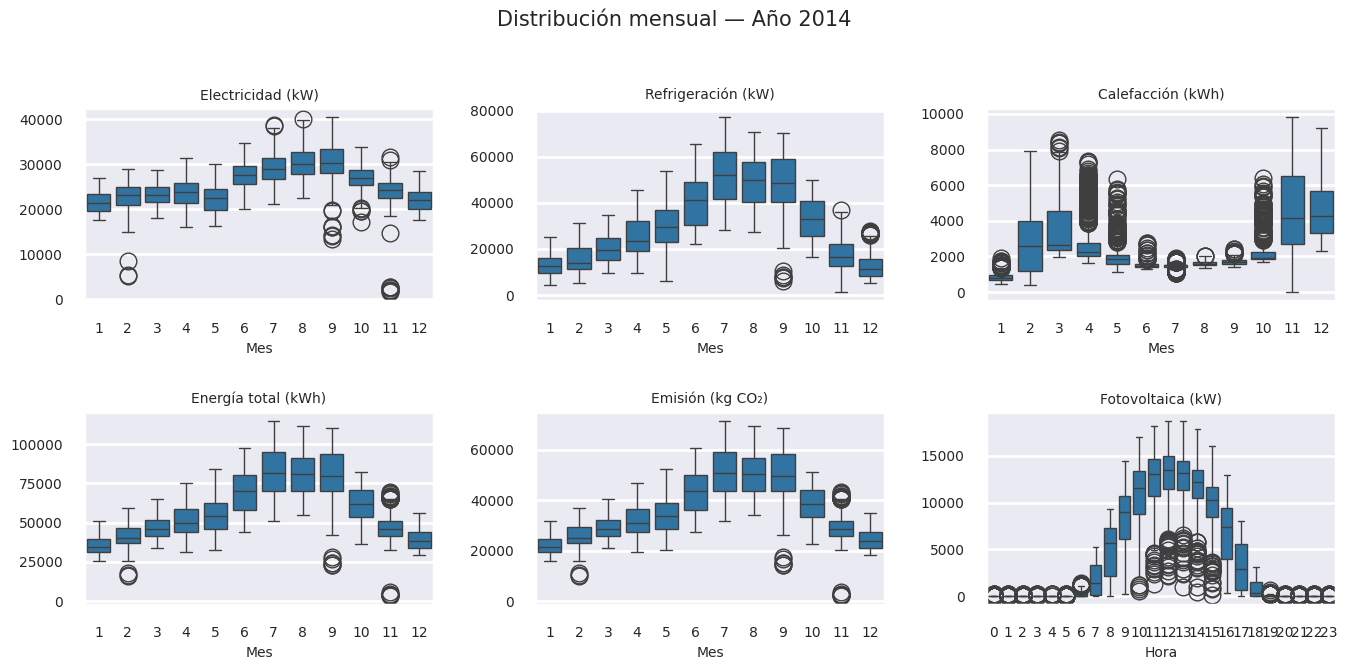

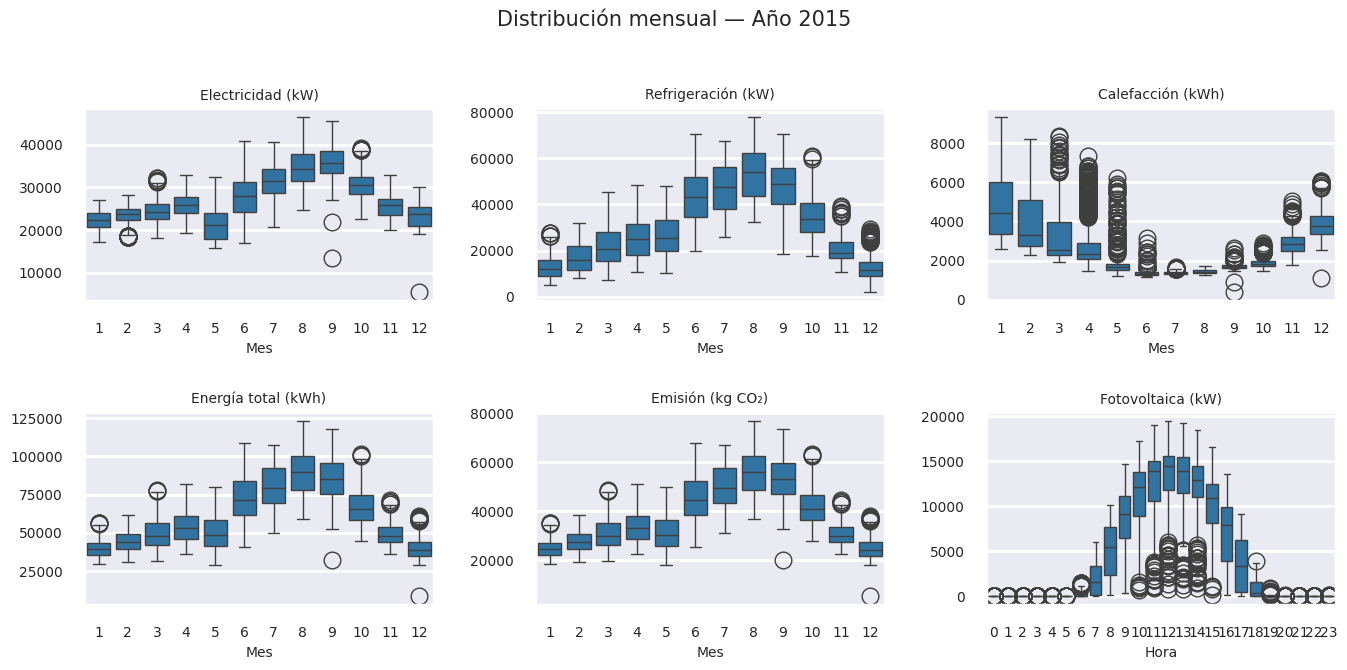

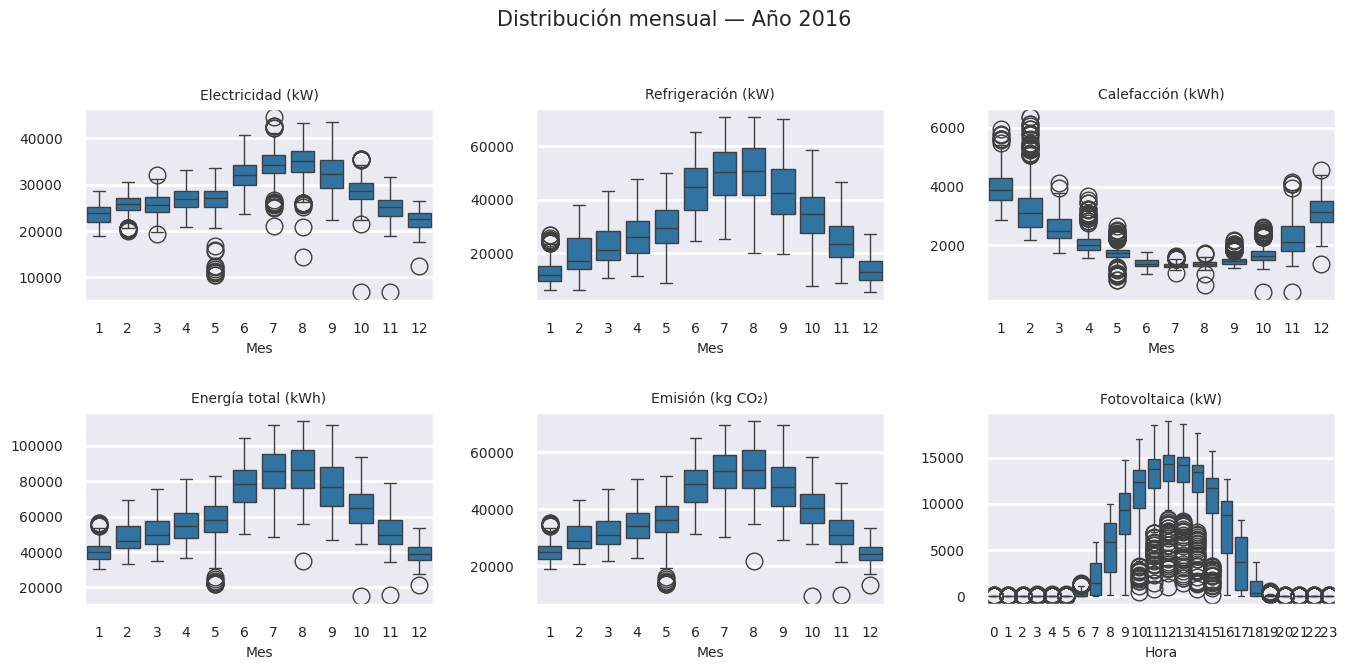

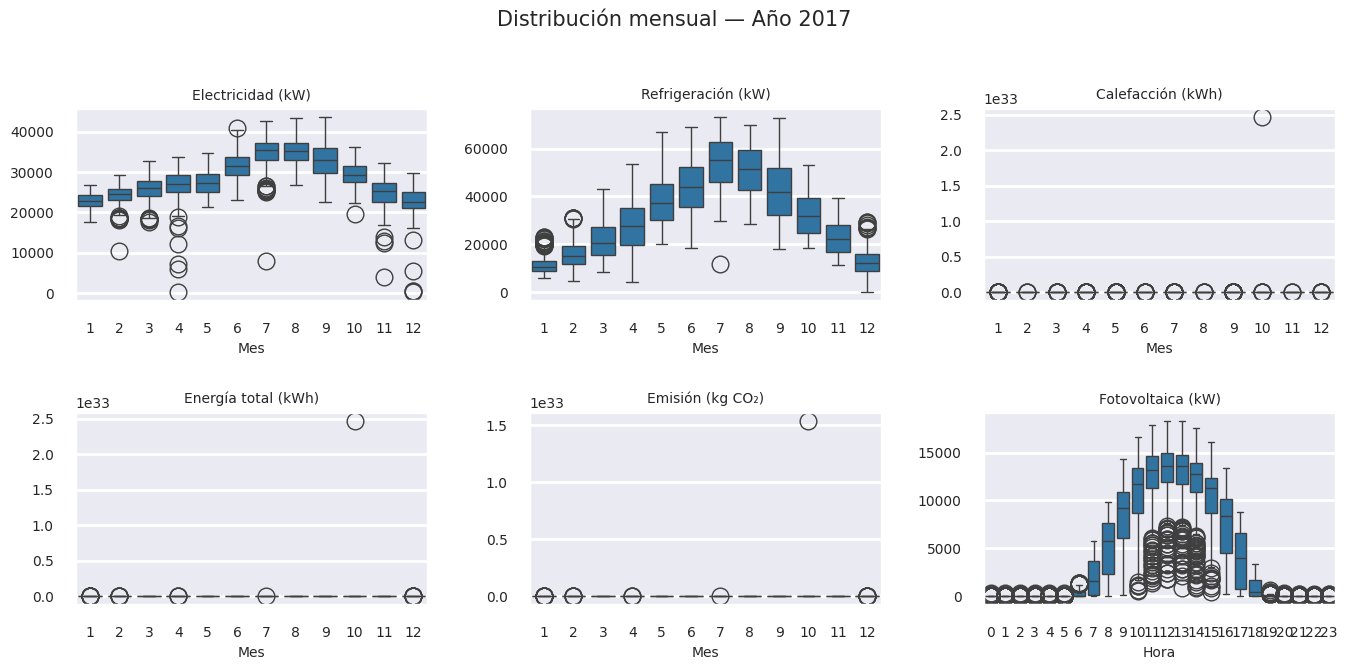

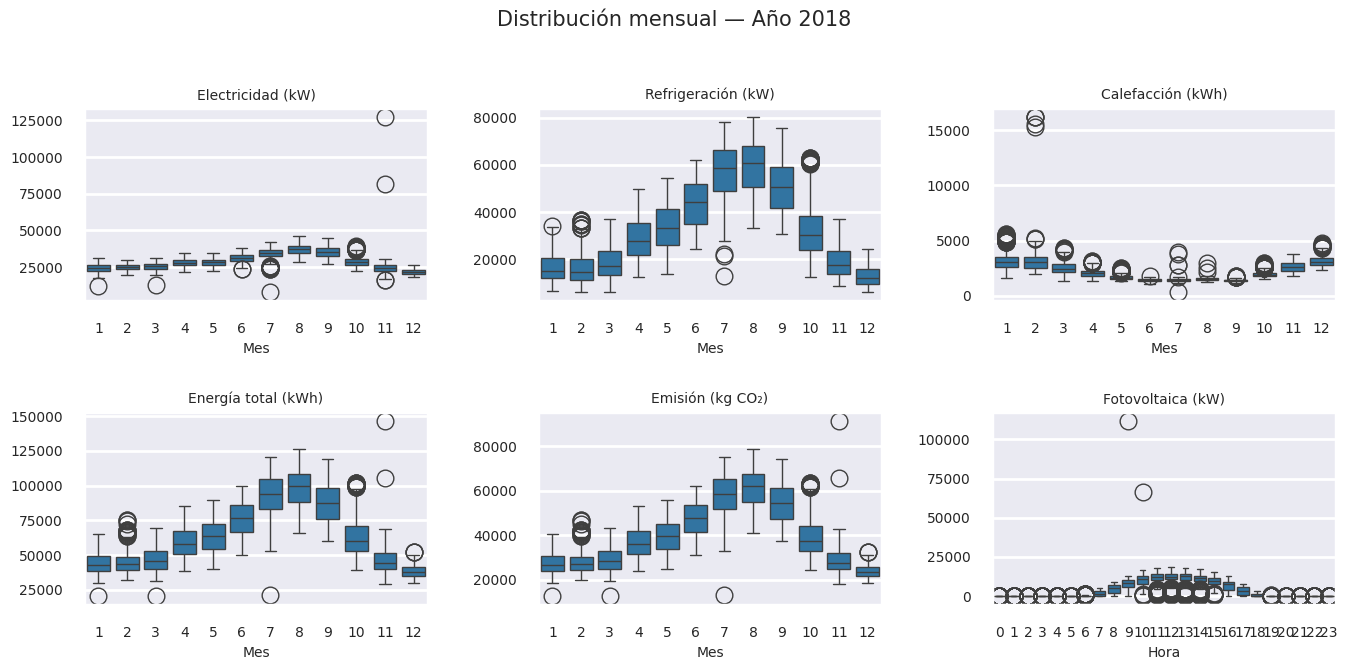

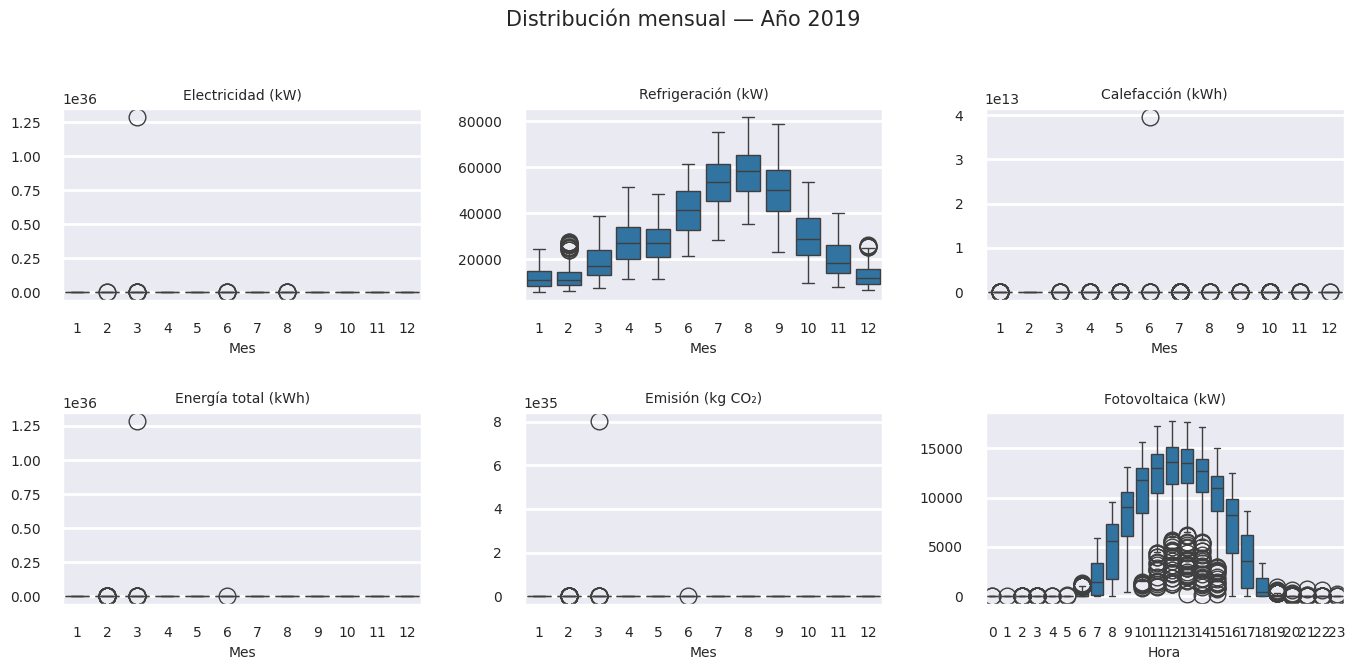

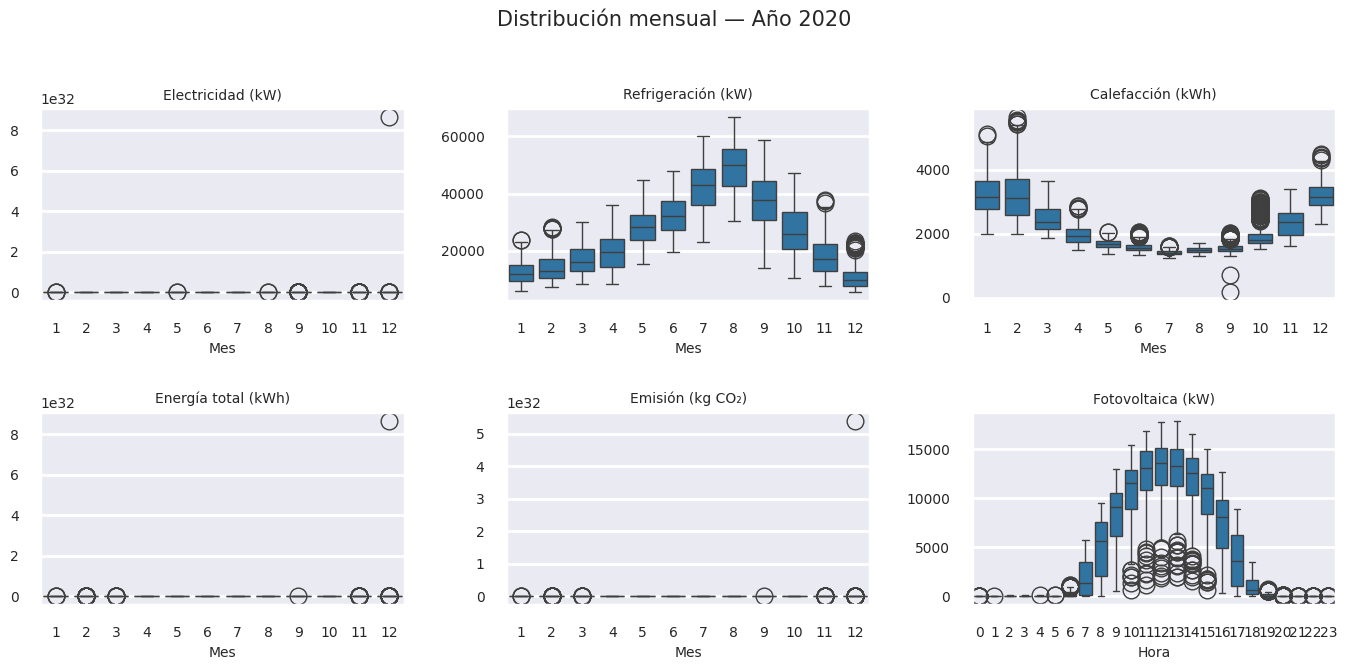

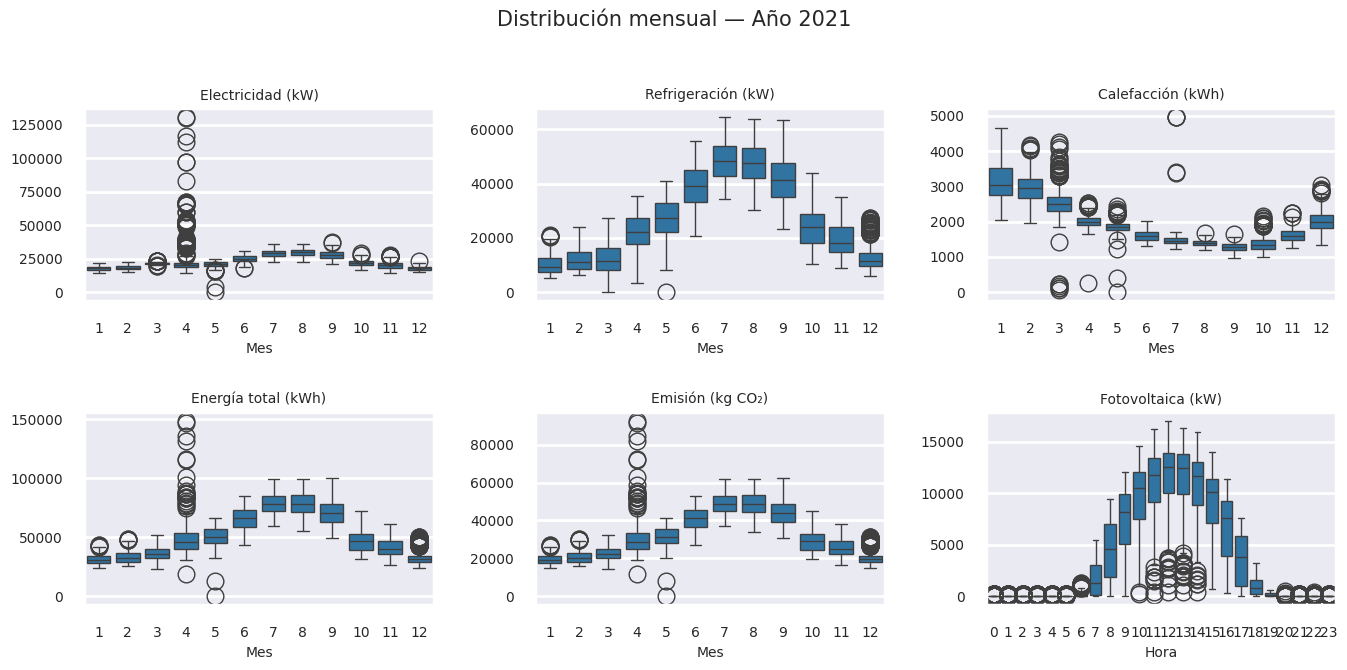

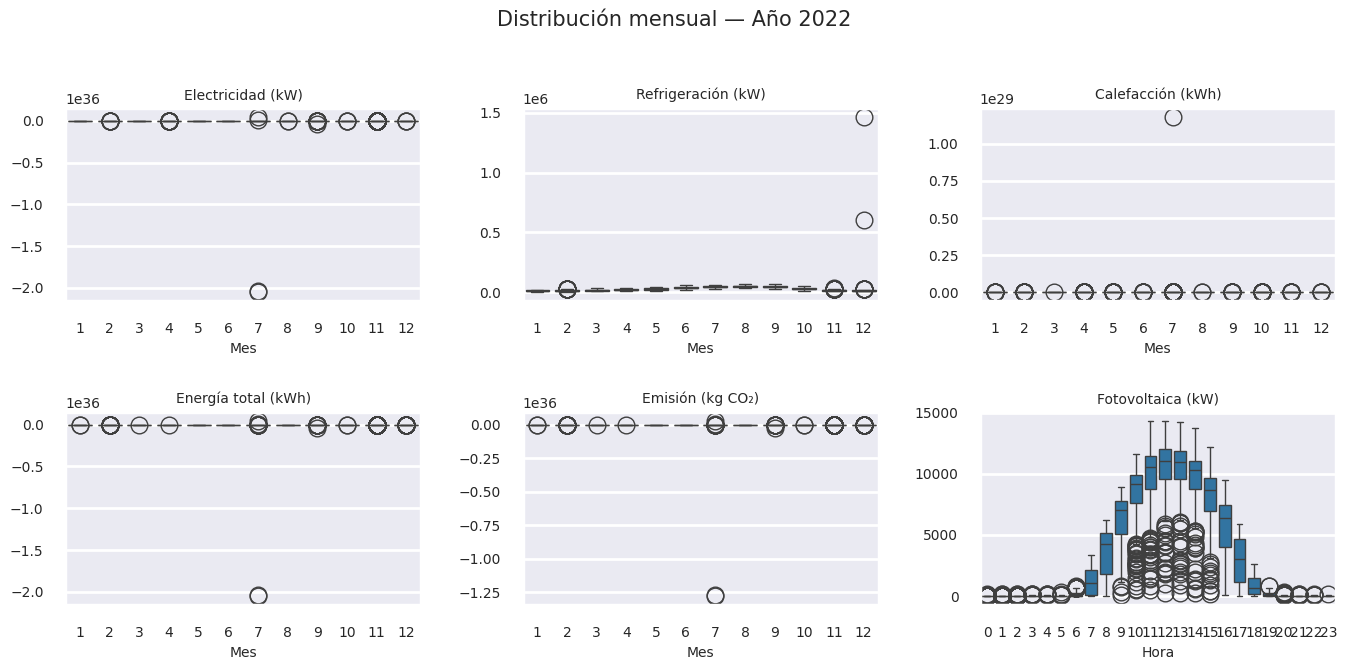

In [7]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
columnas_energia = ['Electricidad (kW)', 'Refrigeración (kW)','Calefacción (kWh)', 'Energía total (kWh)', 'Emisión (kg CO₂)']
anyos = range(2014, 2023)

for y in anyos:
    datos = energia.loc[energia['Año'] == y]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
    axes = axes.flatten()
    
    for i, col in enumerate(columnas_energia):
        ax = axes[i]
        sns.boxplot(x='Mes', y=col, data=datos, ax=ax, whis=1.5, showfliers=True)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Mes", fontsize=10)
        ax.set_ylabel("")
    ax=axes[-1]
    sns.boxplot(x='Hora', y='Fotovoltaica (kW)', data=datos, ax=ax, whis=1.5, showfliers=True)
    ax.set_title('Fotovoltaica (kW)', fontsize=10)
    ax.set_xlabel("Hora", fontsize=10)
    ax.set_ylabel("")
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()

Hacemos lo mismo con gráfico de violín.

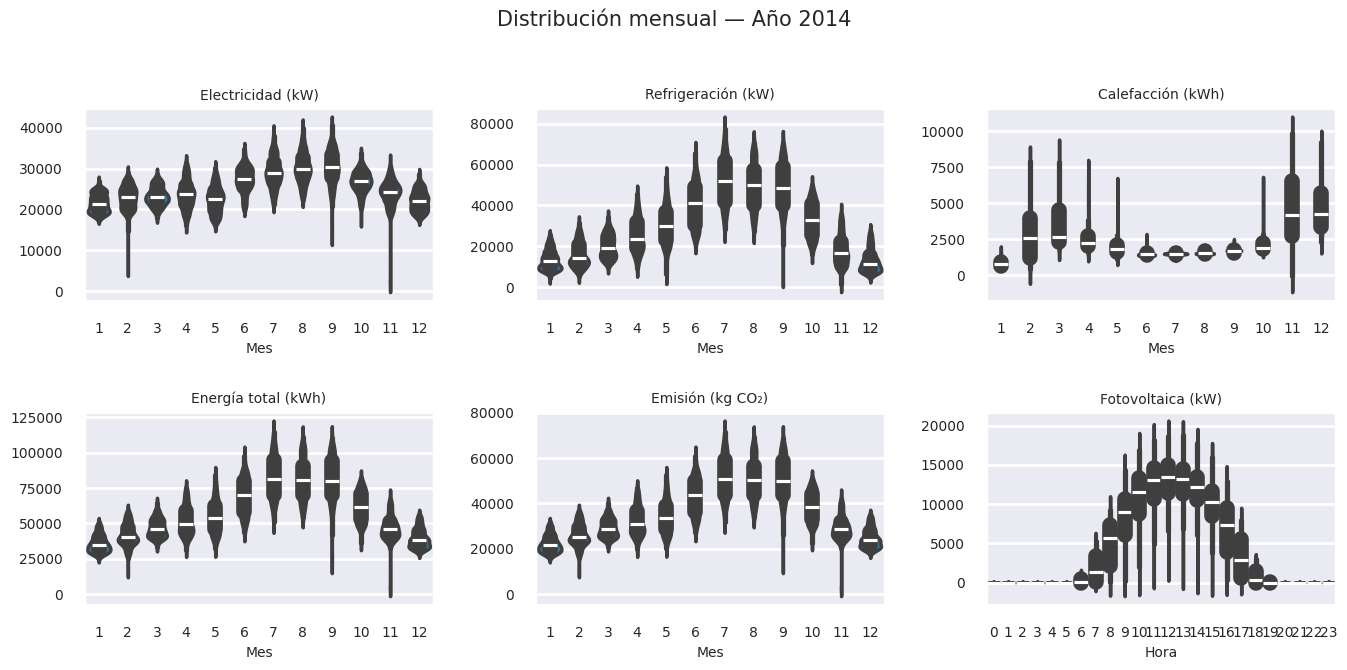

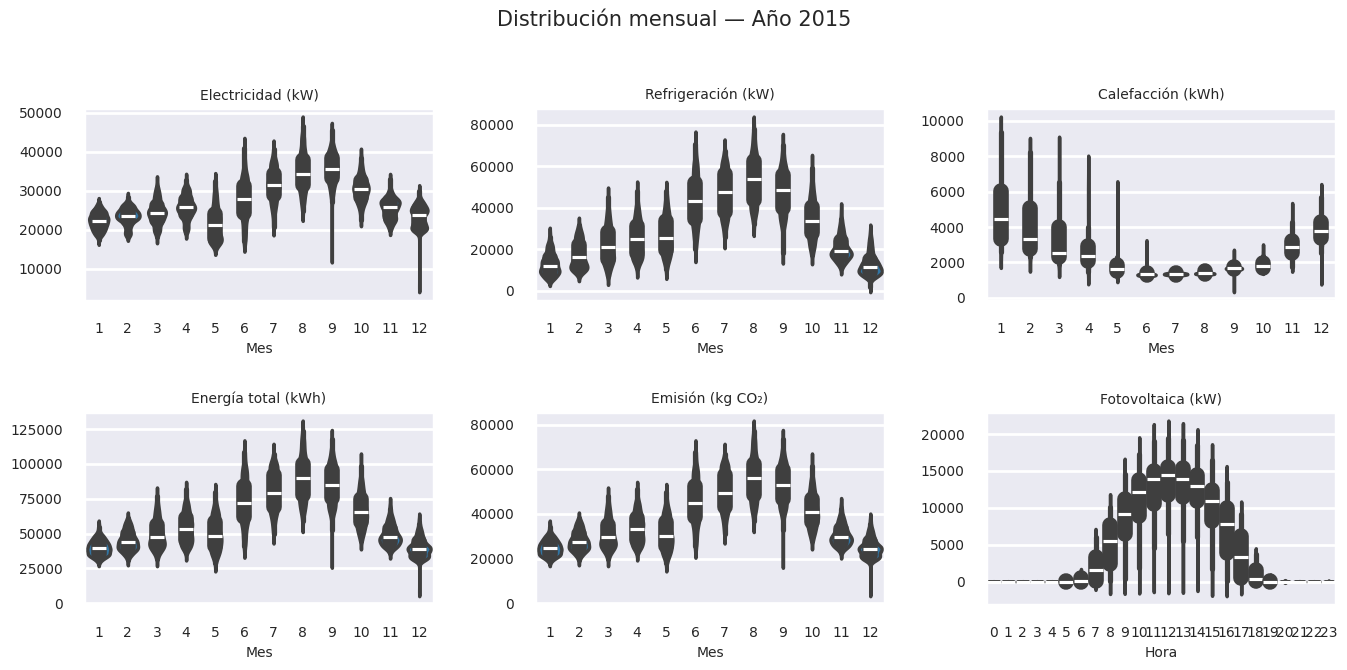

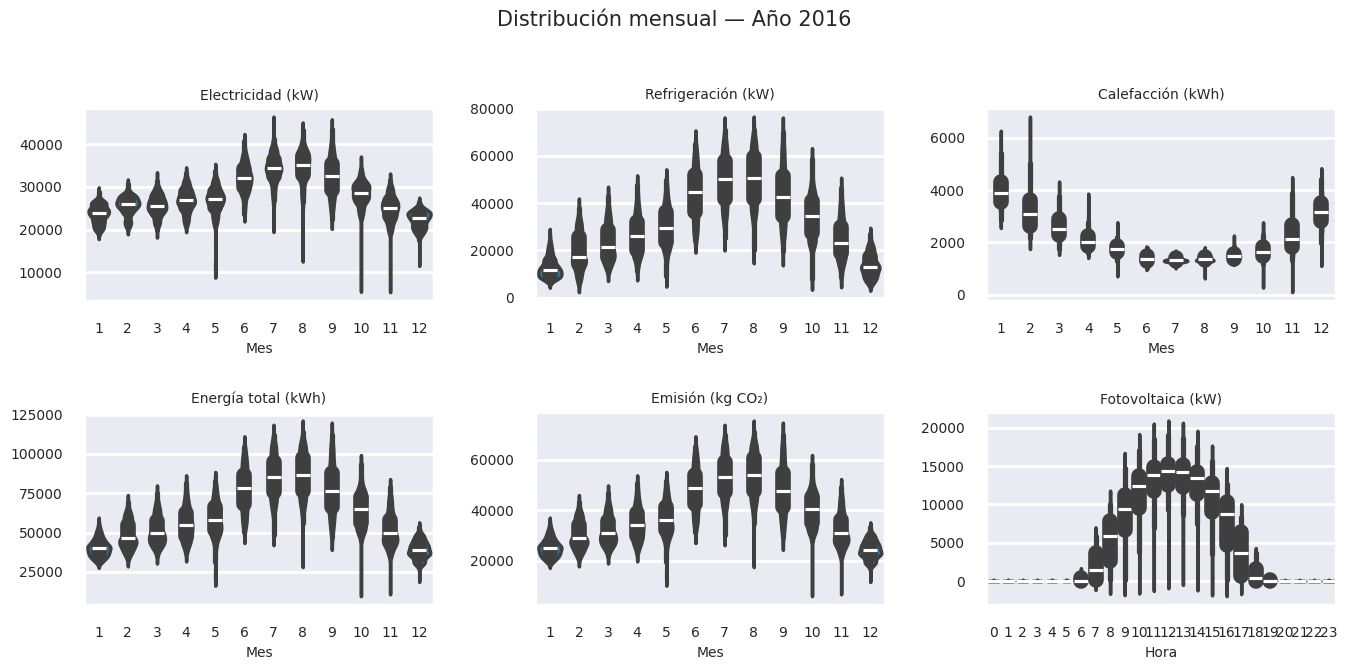

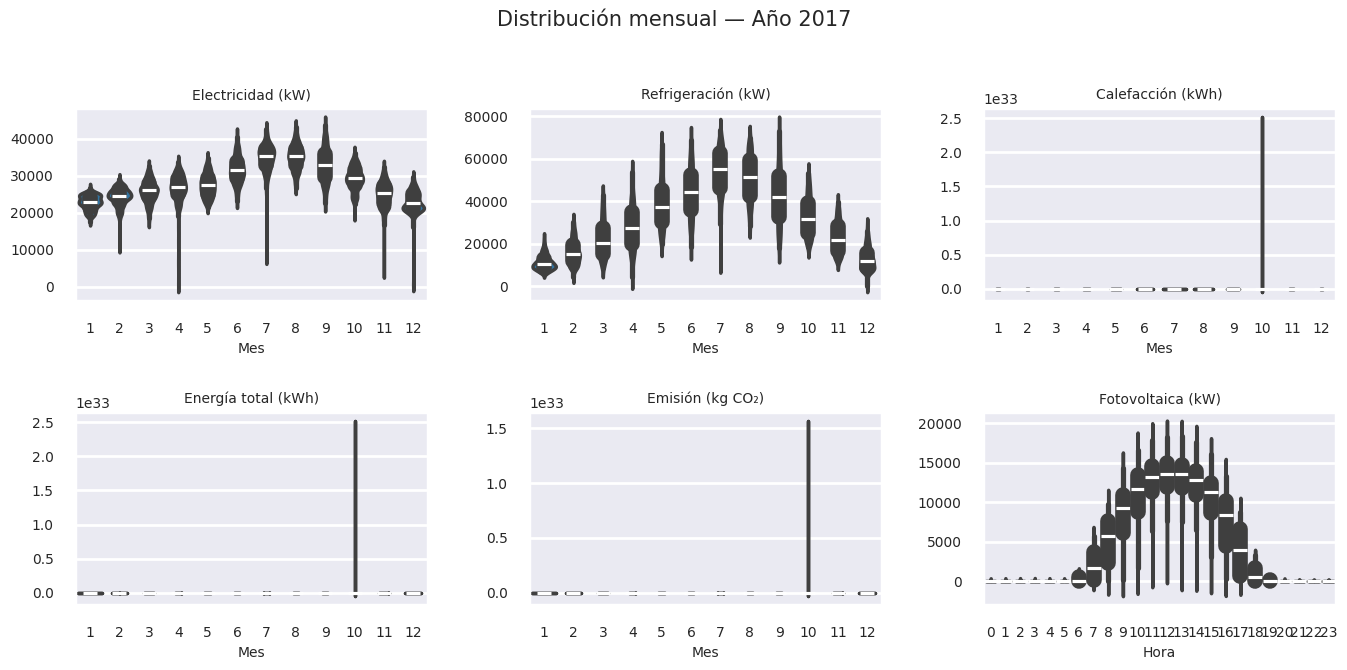

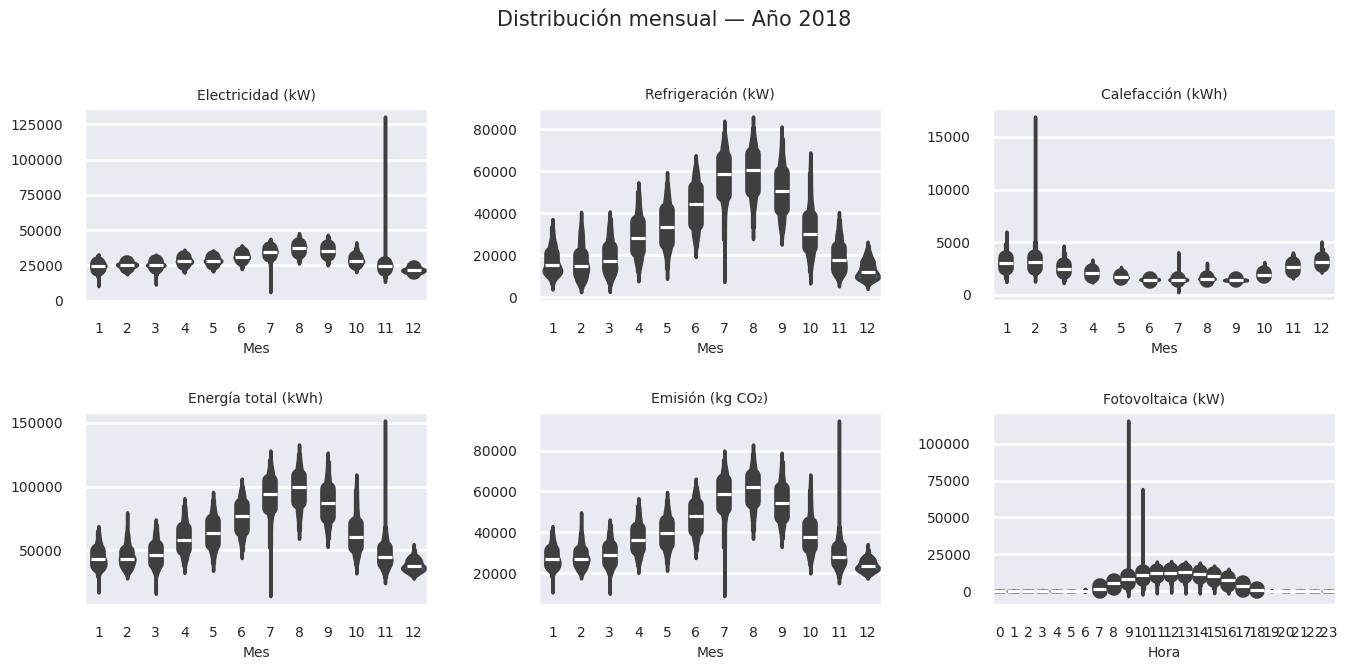

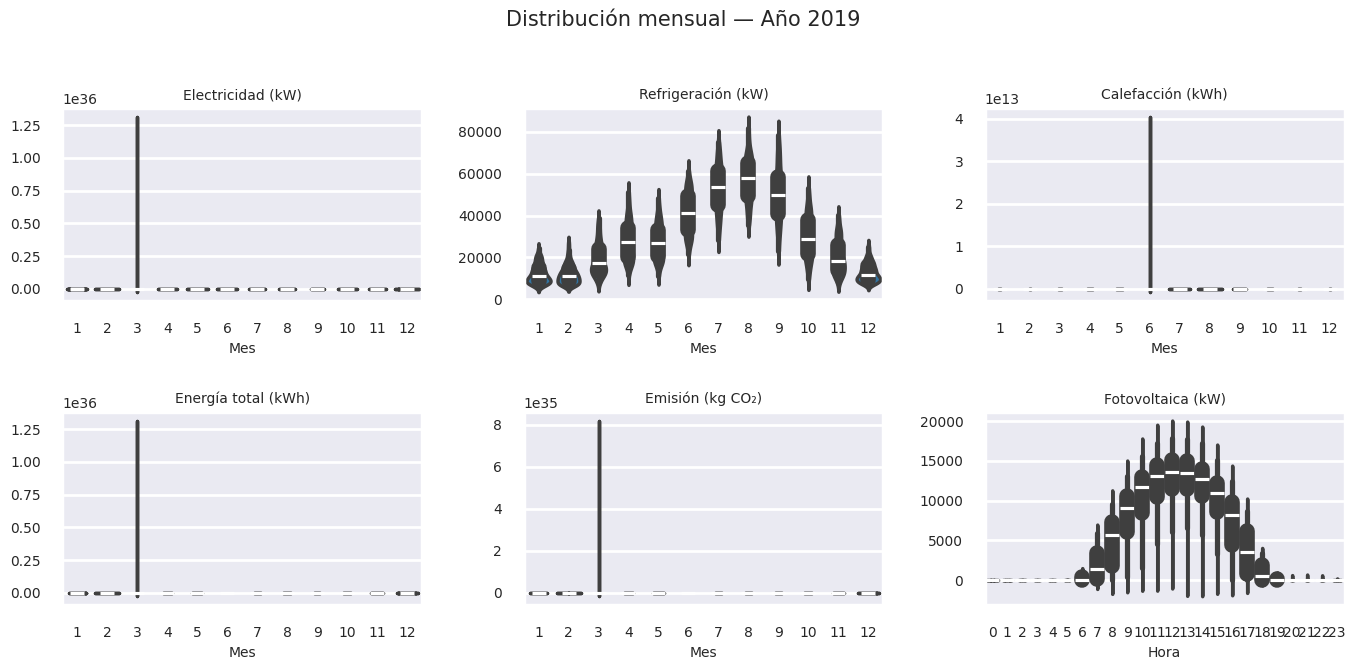

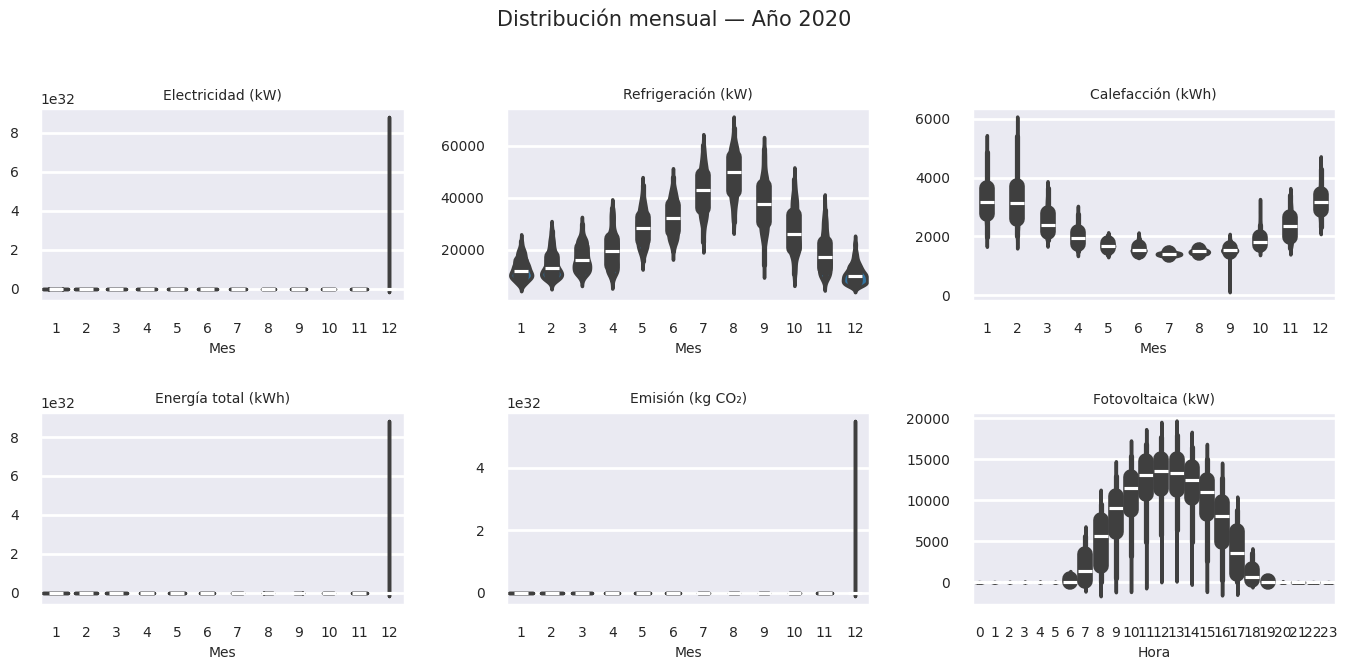

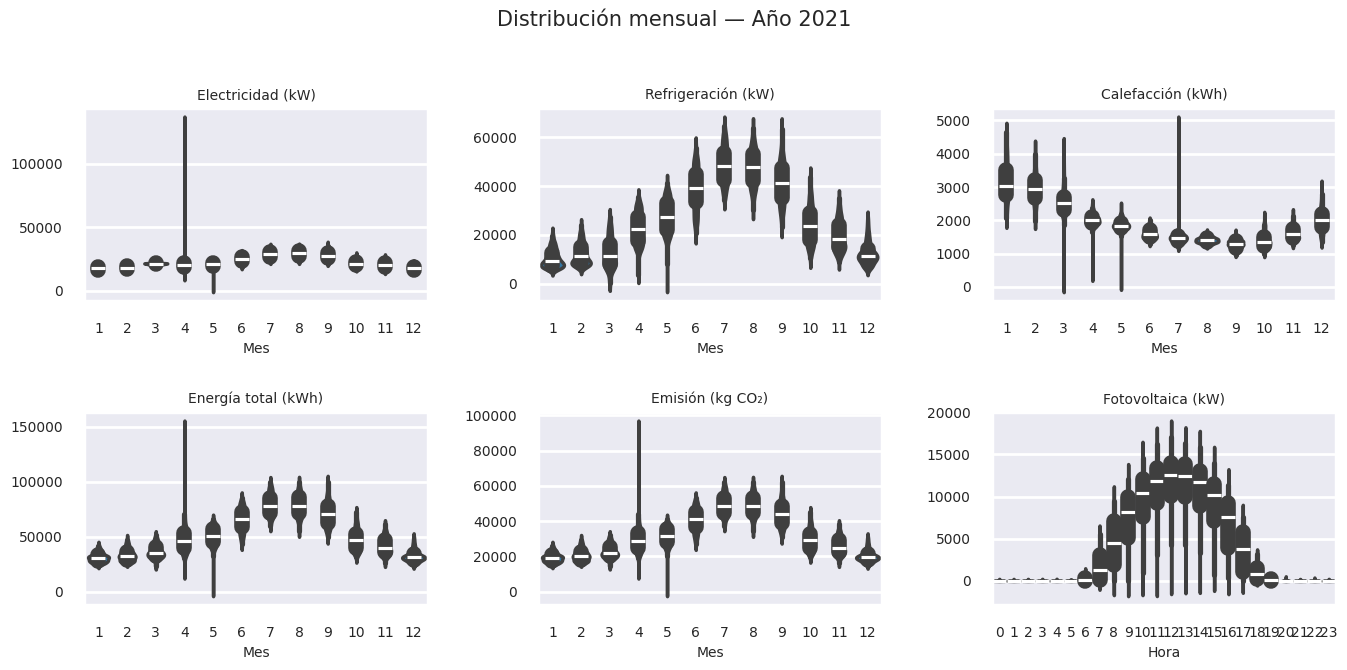

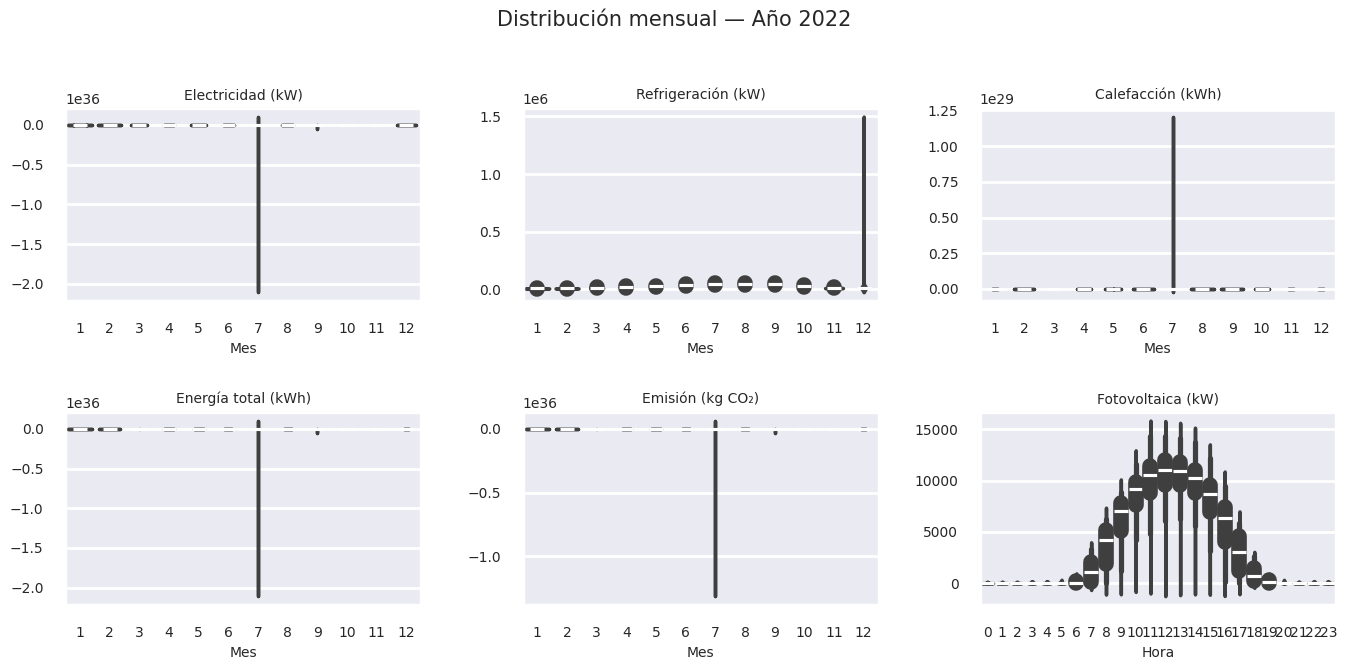

In [8]:
for y in anyos:
    datos = energia.loc[energia['Año'] == y]

    # Creamos una sola figura con 6 subplots (2 filas x 3 columnas)
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
    axes = axes.flatten()  # para indexarlos fácilmente
    
    for i, col in enumerate(columnas_energia):
        ax = axes[i]
        sns.violinplot(x='Mes', y=col, data=datos, ax=ax)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Mes", fontsize=10)
        ax.set_ylabel("")
    ax=axes[-1]
    sns.violinplot(x='Hora', y='Fotovoltaica (kW)', data=datos, ax=ax)
    ax.set_title('Fotovoltaica (kW)', fontsize=10)
    ax.set_xlabel("Hora", fontsize=10)
    ax.set_ylabel("")
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()

Podemos observar que tenemos bastantes valores que no son correctos por lo que debemos decidir que hacer con ellos.<br>

Lo primero de todo es corregir los valores negativos ya que no es posible que en una variable fisica se den estos valores.

In [ ]:
columnas_energia_todas = columnas_energia.copy()
columnas_energia_todas.append('Fotovoltaica (kW)')

def impute_column(series: pd.Series, colname: str) -> pd.Series:
    s =series.copy()
    s = s.interpolate(
        method='time',          # pendiente basada en el tiempo real (segundos)
        limit_direction='both', # rellena hacia dentro y bordes con soporte
        limit_area='inside'     # evita extrapolar fuera de los datos
    )
    return s

def impute_fotovoltaica(series: pd.Series, horas_diurnas_mask: pd.Series) -> pd.Series:
    s = series.copy()
    # Nocturnas = 0 (coherencia física). No tocamos valores diurnos aquí.
    # Interpolación solo en diurnas (evita puentes a través de la noche)
    s_diurnas = s.where(horas_diurnas_mask)
    s_diurnas = s_diurnas.interpolate(
        method='time',
        limit_direction='both',
        limit_area='inside'
    )
    # Actualiza únicamente los puntos diurnos interpolados
    s.update(s_diurnas)
    return s

ventana_horas = 24            # mediana/mad sobre 24h
umbral_k = 4.0                # robust z-score: k=4 (más conservador)
percentil_alto = 0.995        # P99.5 para winsorización

horas_diurnas = energia.index.hour.isin(range(7, 19))

for col in columnas_energia_todas:
    # Bandera de inconsistencias
    energia[f"inconsistente_{col}"] = False

    s = energia[col].copy()

    mask_neg = (s < 0)
    energia[f"inconsistente_{col}"] = energia[f"inconsistente_{col}"] | mask_neg
    s.loc[mask_neg] = np.nan

    if col == 'Fotovoltaica (kW)':
        s_dia = s.where(horas_diurnas)
        # Mediana móvil y residuos (diurnas)
        rol_med = s_dia.rolling(window=ventana_horas, center=True,
                                min_periods=int(ventana_horas*0.5)).median()
        resid = s_dia - rol_med

        # MAD robusta (diurnas)
        mad = resid.rolling(window=ventana_horas, center=True,
                            min_periods=int(ventana_horas*0.5)) \
                   .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)

        mad_adj = (1.4826 * mad).replace(0, np.nan)
        z_rob = resid / mad_adj

        mask_mad_pos = (z_rob > umbral_k)            # detectado solo en diurnas (porque z_rob es NaN en noches)
        q_high = s.loc[horas_diurnas].quantile(percentil_alto)  # percentil en diurnas
        mask_pct_pos = (s > q_high) & horas_diurnas             # umbral solo en diurnas

        # Máscara final de outlier positivo (excluye noches)
        mask_pos = (mask_mad_pos.fillna(False)) | (mask_pct_pos.fillna(False))

        # Marca inconsistencias y CAPA al percentil alto (winsorización) solo en diurnas
        energia[f"inconsistente_{col}"] = energia[f"inconsistente_{col}"] | mask_pos
        s.loc[mask_pos] = np.minimum(s.loc[mask_pos], q_high)

        # Re-imputación: SOLO diurnas; noches = 0
        inicial_na = s.isna()
        s_imp = impute_fotovoltaica(s, horas_diurnas_mask=horas_diurnas)
        final_na = s_imp.isna()

        energia[col] = s_imp

        # Bandera de imputación
        if f"is_imputed_{col}" not in energia.columns:
            energia[f"is_imputed_{col}"] = False
        energia[f"is_imputed_{col}"] = energia[f"is_imputed_{col}"] | ((~final_na) & inicial_na)
    else:
        # Mediana móvil y residuos
        rol_med = s.rolling(window=ventana_horas, center=True,
                            min_periods=int(ventana_horas*0.5)).median()
        resid = s - rol_med

        # MAD (Median Absolute Deviation)
        mad = resid.rolling(window=ventana_horas, center=True,
                        min_periods=int(ventana_horas*0.5)) \
            .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)

        # z-score robusto (evitar división por 0)
        mad_adj = 1.4826 * mad
        mad_adj = mad_adj.replace(0, np.nan)
        z_rob = resid / mad_adj

        mask_mad_pos = z_rob > umbral_k     # solo positivos extremos

        q_high = s.quantile(percentil_alto)
        mask_pct_pos = s > q_high

        # Máscara final (union de criterios)
        mask_pos = (mask_mad_pos.fillna(False)) | (mask_pct_pos.fillna(False))
        energia[f"inconsistente_{col}"] = energia[f"inconsistente_{col}"] | mask_pos
        s.loc[mask_pos] = np.minimum(s.loc[mask_pos], q_high)


        # Re-imputación de los NaN recién creados
        inicial_na = s.isna()
        s_imp = impute_column(s, col)
        final_na = s_imp.isna()
        energia[col] = s_imp

        # Bandera de imputación (actualizada)
        if f"is_imputed_{col}" not in energia.columns:
            energia[f"is_imputed_{col}"] = False
        energia[f"is_imputed_{col}"] = energia[f"is_imputed_{col}"] | ((~final_na) & inicial_na)


In [10]:

for c in columnas_energia_todas:
    energia[col] = energia[c].clip(lower=0)

# Reporte
print("Corrección de inconsistencias completada.")
for col in columnas_energia_todas:
    inc = int(energia[f"inconsistente_{col}"].sum())
    imp = int(energia[f"is_imputed_{col}"].sum())
    print(f"{col}: inconsistentes corregidos = {inc}, imputados (incluye faltantes previos) = {imp}")

Corrección de inconsistencias completada.
Electricidad (kW): inconsistentes corregidos = 593, imputados (incluye faltantes previos) = 120
Refrigeración (kW): inconsistentes corregidos = 406, imputados (incluye faltantes previos) = 17
Calefacción (kWh): inconsistentes corregidos = 2435, imputados (incluye faltantes previos) = 24
Energía total (kWh): inconsistentes corregidos = 507, imputados (incluye faltantes previos) = 118
Emisión (kg CO₂): inconsistentes corregidos = 507, imputados (incluye faltantes previos) = 118
Fotovoltaica (kW): inconsistentes corregidos = 28885, imputados (incluye faltantes previos) = 17


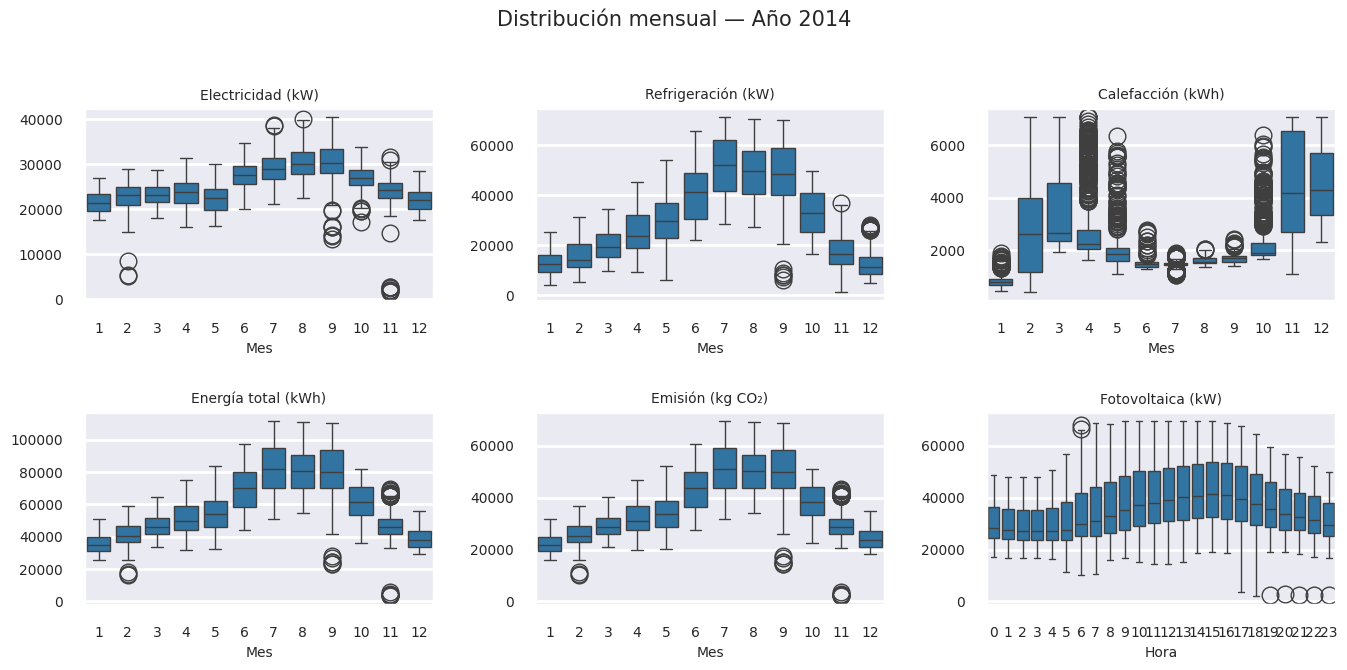

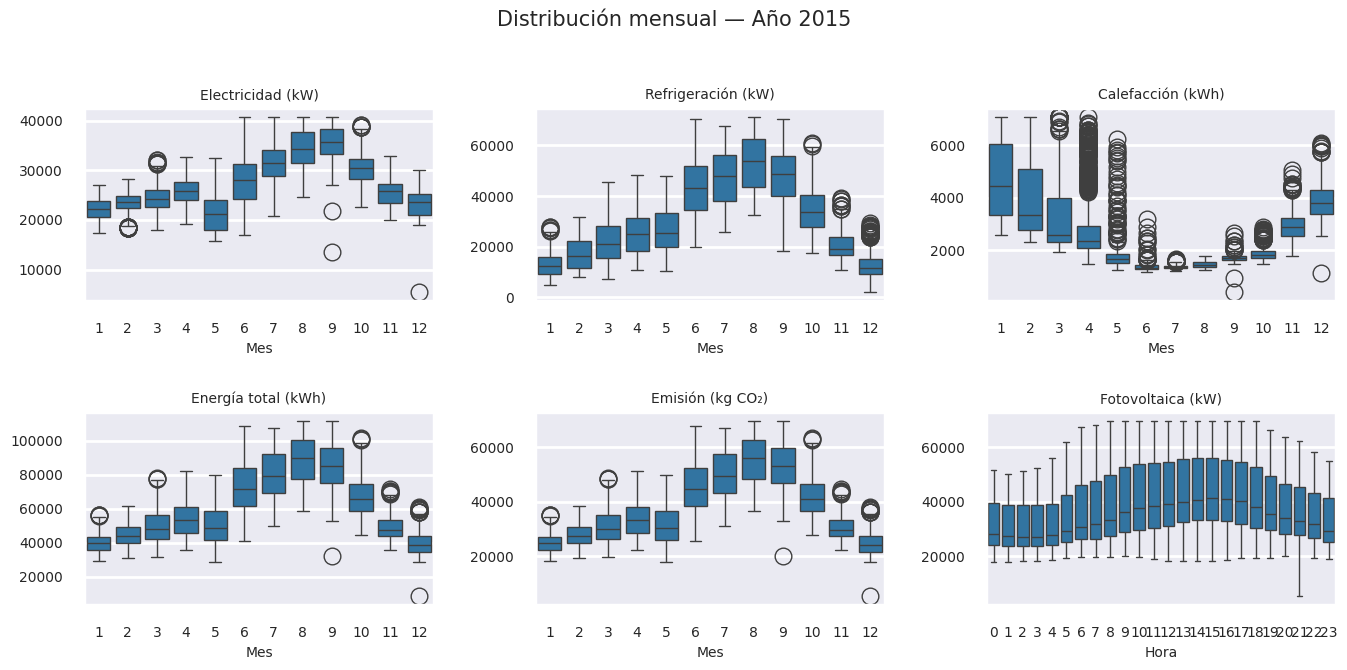

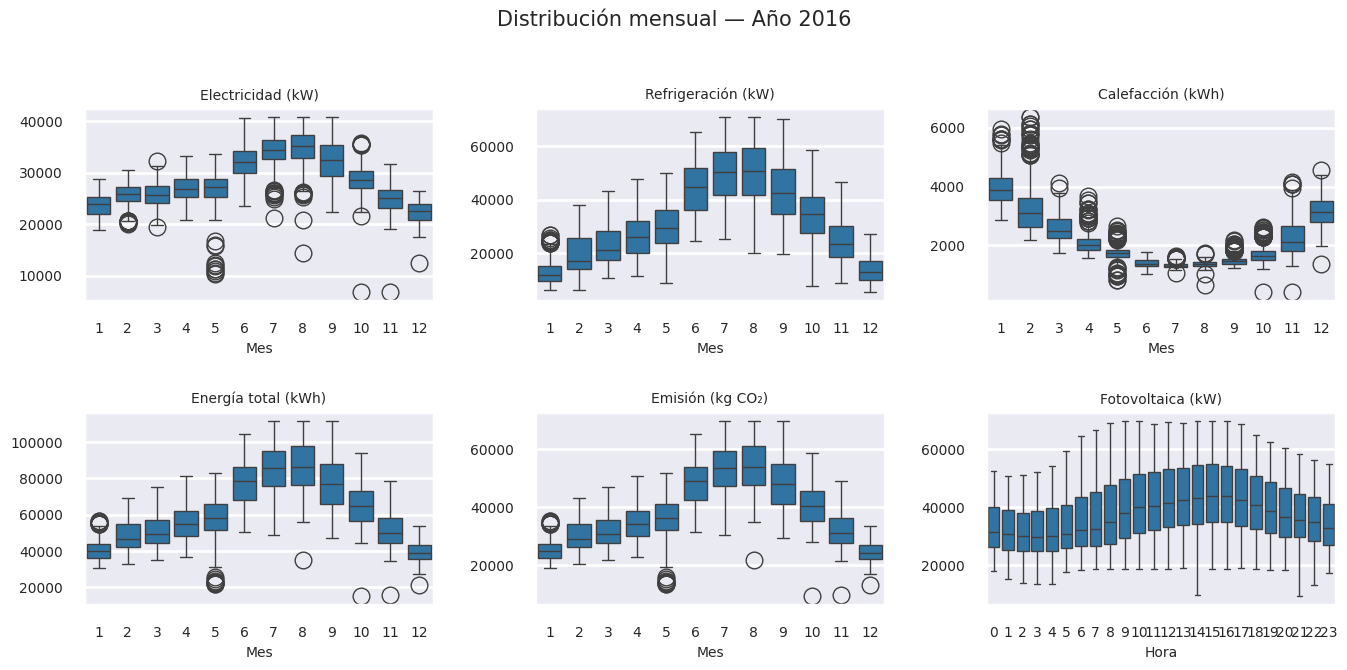

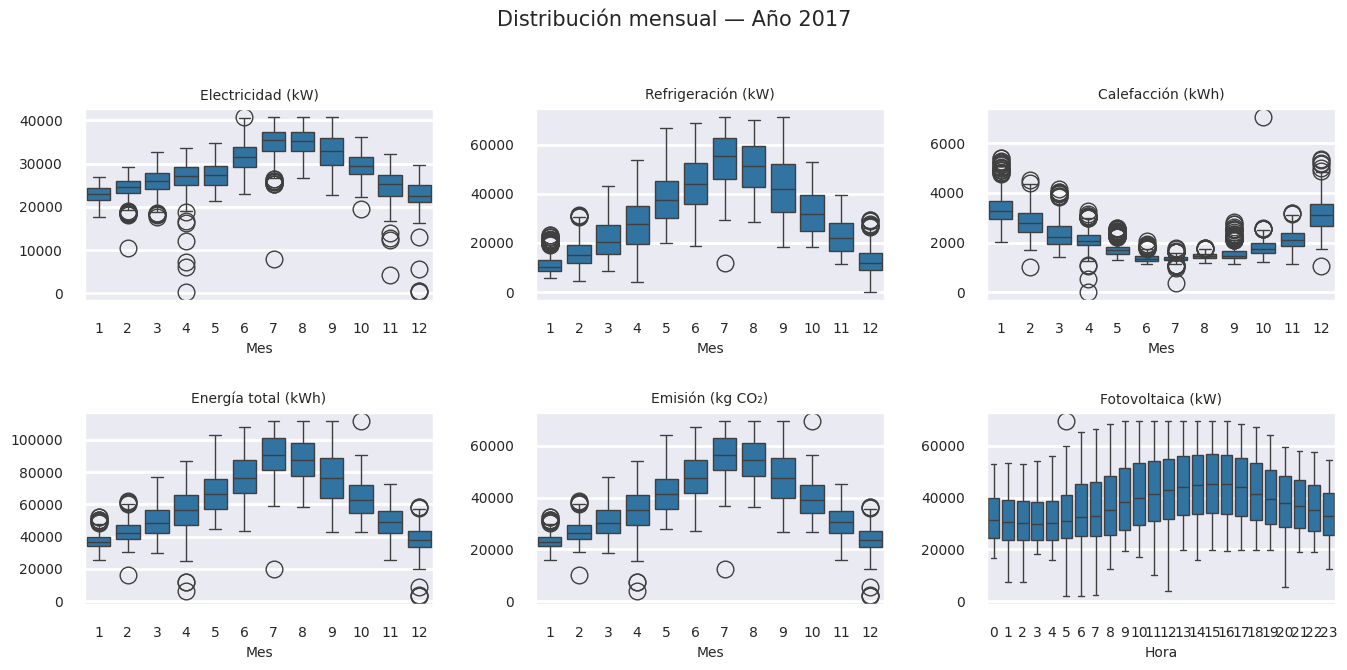

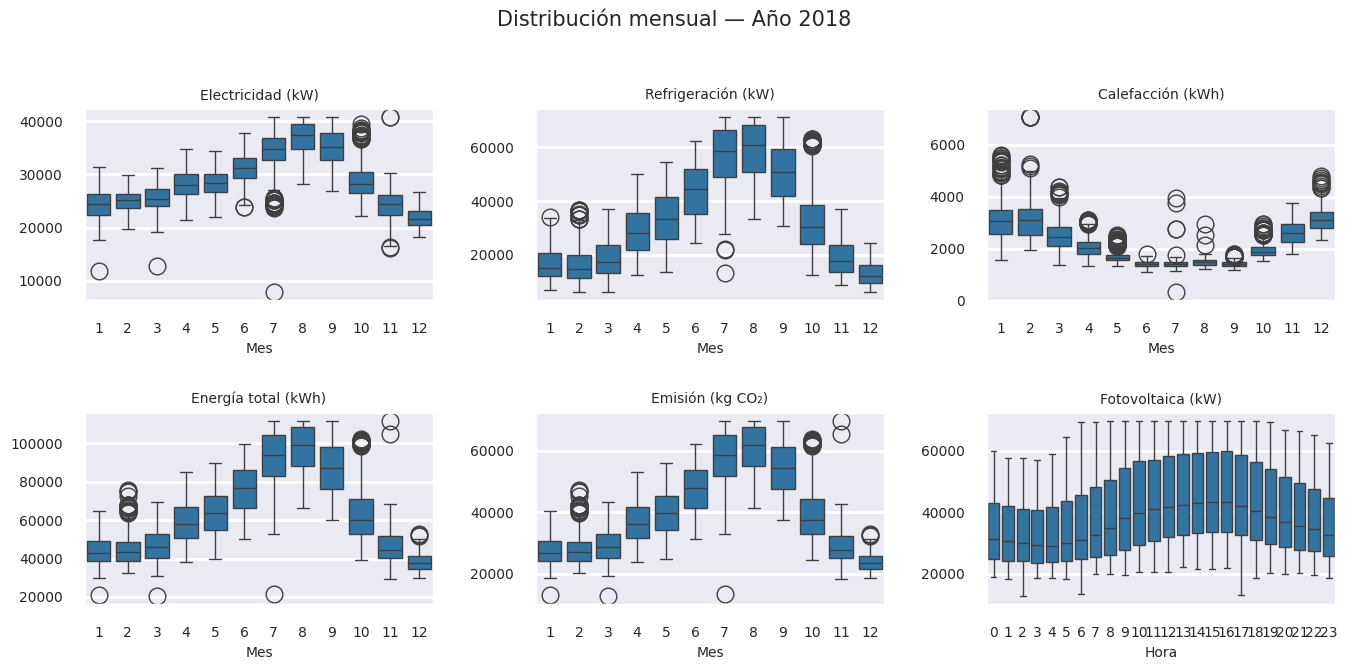

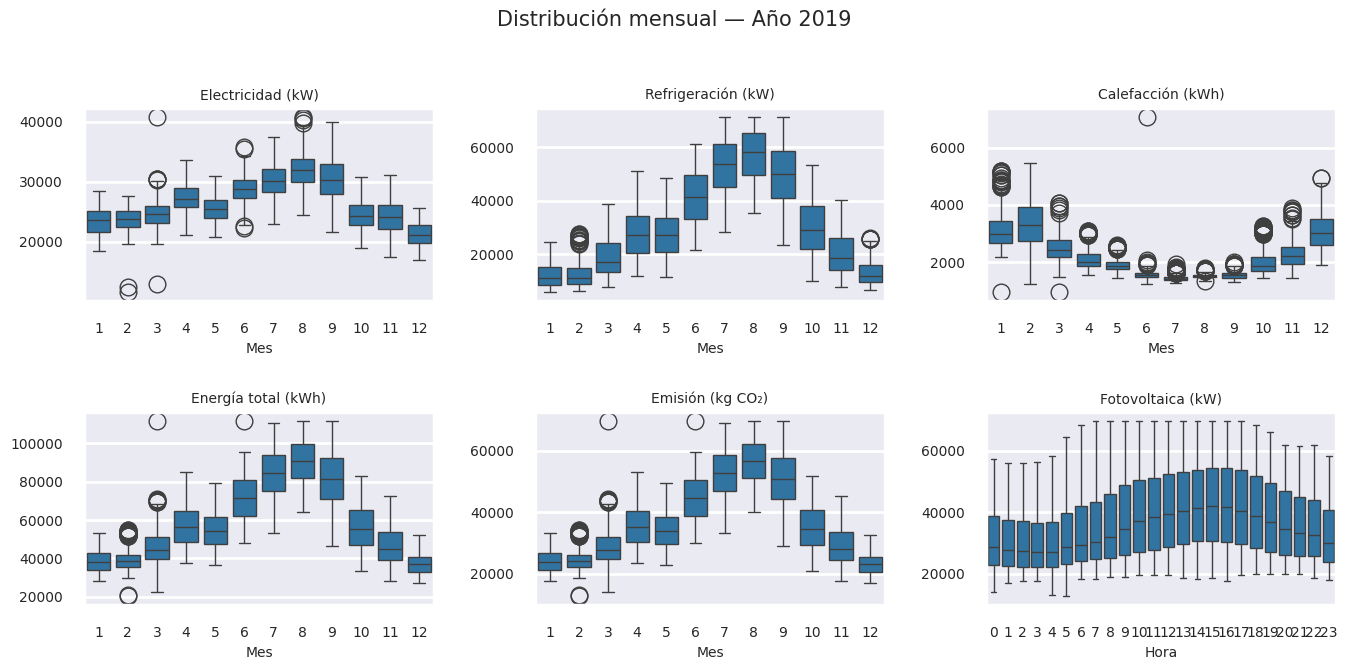

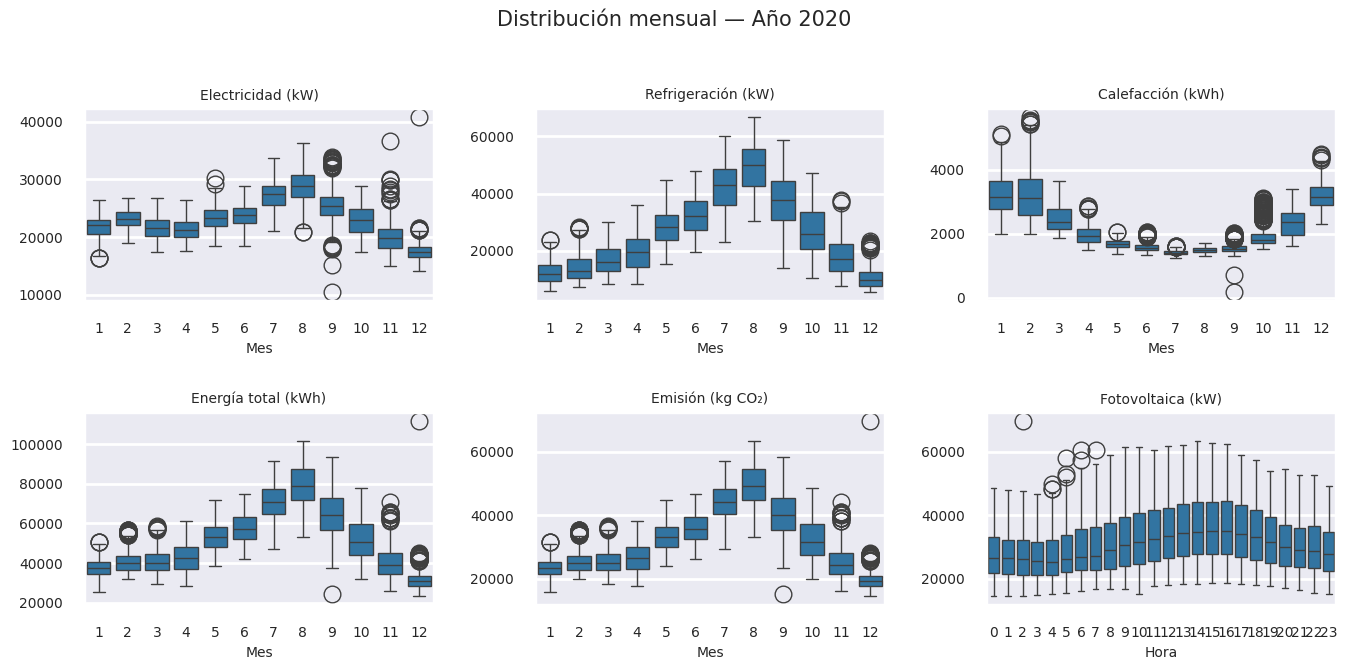

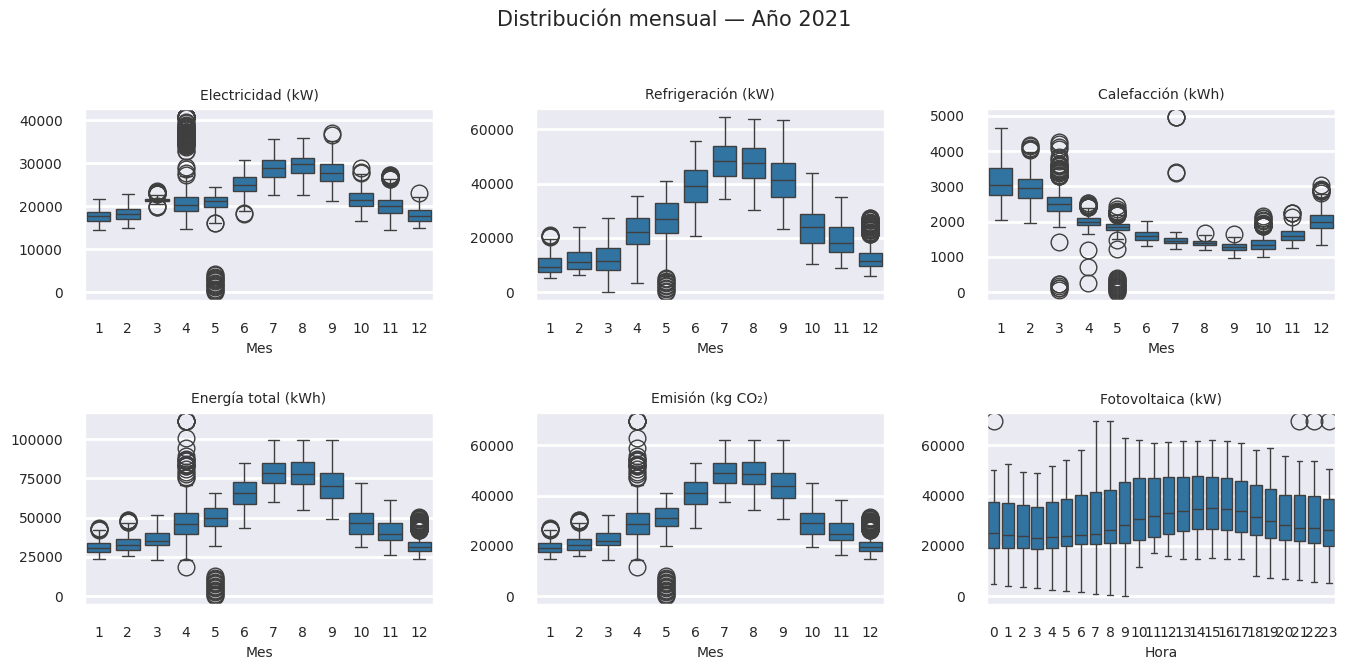

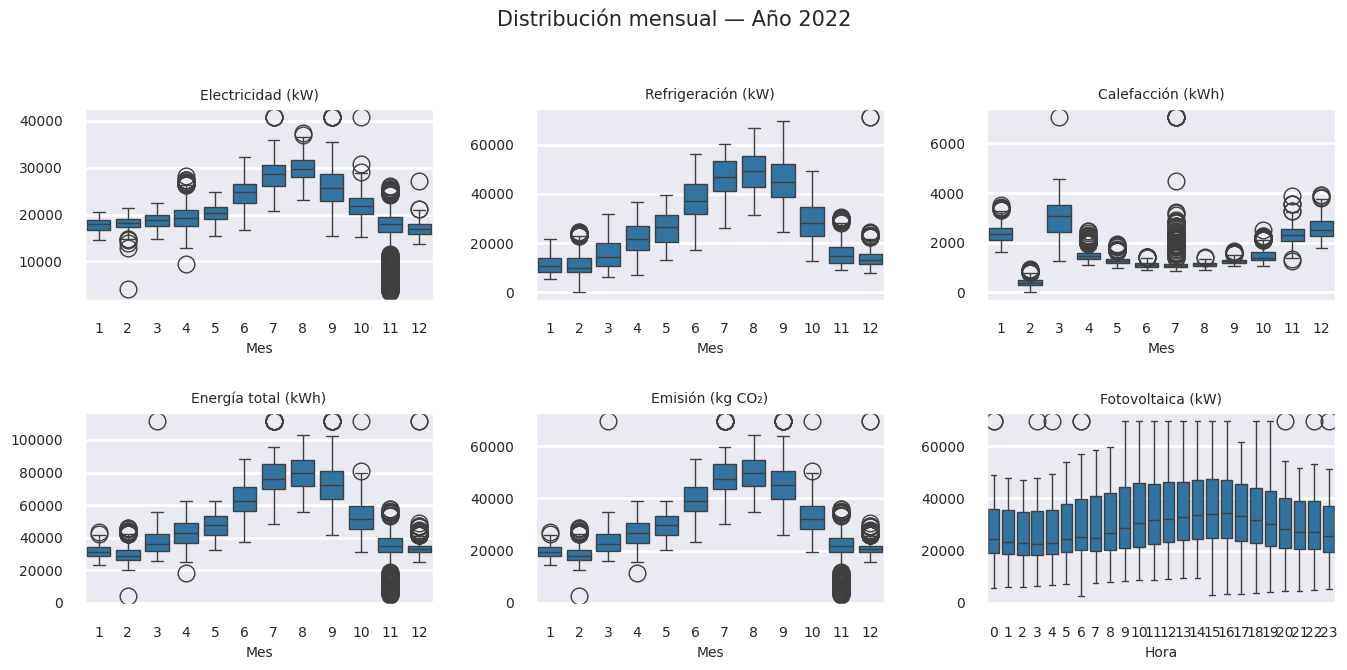

In [11]:
for y in anyos:
    datos = energia.loc[energia['Año'] == y]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
    axes = axes.flatten()
    
    for i, col in enumerate(columnas_energia):
        ax = axes[i]
        sns.boxplot(x='Mes', y=col, data=datos, ax=ax, whis=1.5, showfliers=True)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Mes", fontsize=10)
        ax.set_ylabel("")
    ax=axes[-1]
    sns.boxplot(x='Hora', y='Fotovoltaica (kW)', data=datos, ax=ax, whis=1.5, showfliers=True)
    ax.set_title('Fotovoltaica (kW)', fontsize=10)
    ax.set_xlabel("Hora", fontsize=10)
    ax.set_ylabel("")
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()

In [12]:
#solo para que salga el bloque de imagenes completo, que se cortaba
print(horas_diurnas)

[False False False ... False False False]
